# Stage 07 - Outliers, Risk, Assumptions

**Dataset:** `data/raw/outliers_homework.csv` - 115 business days of synthetic daily
returns, generated by the Setup cell below with `np.random.seed(17)`.
**Detection code:** `src/outliers.py` (the stretch goal - functions are packaged, not
pasted into the notebook).

The starter's sample implementations already worked. It asked for five specific
improvements, all of which are in `src/outliers.py`:

| # | Problem in the starter | What changed |
|---|---|---|
| 1 | Empty series silently returns an empty mask | `ValueError` - an empty answer reads as "no outliers found", which is a wrong answer wearing a right answer's clothes |
| 2 | `NaN` behaviour unstated | Documented and enforced: **NaN is never an outlier**. Missing is not extreme, and Stage 06 already owns missingness |
| 3 | `ddof=0` used without explanation | Explained in the docstring: population sd, because this describes the sample in hand rather than inferring about a population |
| 4 | `k` and `threshold` unvalidated | Rejected if not positive - a negative `k` inverts the test and flags every ordinary point |
| 5 | `winsorize_series` doesn't check `lower < upper` | Validated - reversed quantiles make `.clip()` return a constant series with no error at all |

**Where this notebook ends up:** the two detection rules disagree, the z-score rule turns
out not to respond to its own threshold, filtering makes R² collapse while leaving the
slope almost unchanged, and winsorizing one column of a two-column relationship nearly
triples the fitted slope. Each of those is a result, not a mistake, and the reflection at
the bottom ties them together.

In [1]:
# --- setup ---
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

np.random.seed(17)          # matches the Setup cell; keeps every re-run identical
pd.set_option('display.width', 120)

if '' not in sys.path:
    sys.path.insert(0, '')  # so `from src import outliers` works

os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

print('working from:', os.path.basename(os.getcwd()))

working from: homework07


In [2]:
# --- Setup: generate the dataset (from the starter, unchanged) ---
dates = pd.date_range(start='2022-01-03', end='2022-06-10', freq='B')

np.random.seed(17)
returns = np.random.normal(0, 0.01, size=len(dates))
returns[dates < '2022-05-01'] -= 0.0015          # slight negative drift before May

shock_values = {
    '2022-05-02':  0.1748425237194541,
    '2022-05-03': -0.16825801732486943,
    '2022-05-06': -0.19667220757153227,
    '2022-05-09':  0.21240223590614747,
    '2022-05-12': -0.178729287231294,
}
for d, v in shock_values.items():
    returns[np.where(dates == pd.to_datetime(d))[0][0]] = v

daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

csv_path = os.path.join('data/raw', 'outliers_homework.csv')
if not os.path.exists(csv_path):
    pd.DataFrame({'date': dates,
                  'daily_return': returns,
                  'daily_return_2': daily_return_2}).to_csv(csv_path, index=False)
    print('created', csv_path)
else:
    print('already present:', csv_path)

created data/raw/outliers_homework.csv


**Read the generator before analysing its output.** Three facts are planted in it, and
knowing them is what makes it possible to grade the detection rules rather than just run
them:

1. `daily_return_2 = daily_return * 0.6 + noise` - **the true slope is 0.6.** Any
   treatment that moves the fitted slope away from 0.6 has damaged the relationship.
2. Five shock values are injected, all between **2022-05-02 and 2022-05-12**. There are
   exactly five true outliers and they are *clustered in time*.
3. Returns before May are shifted down by 0.0015 - a mild regime difference that has
   nothing to do with the shocks.

In [3]:
from src import outliers

df = pd.read_csv(csv_path, parse_dates=['date'])
print('shape:', df.shape)
print()
print(df[['daily_return', 'daily_return_2']].describe().round(6).to_string())
df.head()

shape: (115, 3)

       daily_return  daily_return_2
count    115.000000      115.000000
mean      -0.001434       -0.000668
std        0.040579        0.025068
min       -0.196672       -0.115209
25%       -0.008525       -0.005645
50%       -0.000187       -0.000174
75%        0.006368        0.004679
max        0.212402        0.136536


,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


That `std` of 0.0406 on `daily_return` is already suspicious. The generator drew from
`N(0, 0.01)`, so the standard deviation should be near 0.01. Five injected values have
quadrupled it - which is the whole problem with using the standard deviation to find
outliers, and it shows up again in a moment.

## Step 1 - Apply both detection rules

`outlier_report` runs both and shows the bounds each one derived, so the disagreement is
visible rather than inferred.

In [4]:
target_col = 'daily_return'
series = df[target_col]

report = outliers.outlier_report(series, k=1.5, threshold=3.0)
report.round(5)

,lower_bound,upper_bound,n_flagged,pct_flagged
iqr (k=1.5),-0.03086,0.02871,9,7.83
zscore (threshold=3.0),-0.12264,0.11977,5,4.35


In [5]:
df['outlier_iqr'] = outliers.detect_outliers_iqr(series, k=1.5)
df['outlier_z'] = outliers.detect_outliers_zscore(series, threshold=3.0)

print('IQR flagged   :', int(df['outlier_iqr'].sum()))
print('z-score flagged:', int(df['outlier_z'].sum()))
print('both agree on :', int((df['outlier_iqr'] & df['outlier_z']).sum()))
print()
print('true planted shocks: 5')

IQR flagged   : 9
z-score flagged: 5
both agree on : 5

true planted shocks: 5


### The two rules disagree, and one of them is right

The z-score rule found exactly the five planted shocks. The IQR rule found those five plus
four more. Since the generator tells us the truth, those four extra are **false
positives** - and they are worth looking at individually rather than as a count.

In [6]:
print('flagged by IQR but NOT by z-score:')
print(df.loc[df['outlier_iqr'] & ~df['outlier_z'], ['date', target_col]]
        .to_string(index=False))
print()
print('flagged by both (the five planted shocks):')
print(df.loc[df['outlier_iqr'] & df['outlier_z'], ['date', target_col]]
        .to_string(index=False))

flagged by IQR but NOT by z-score:
      date  daily_return
2022-03-01      0.031952
2022-03-31     -0.031101
2022-05-04     -0.033999
2022-05-11      0.028711

flagged by both (the five planted shocks):
      date  daily_return
2022-05-02      0.174843
2022-05-03     -0.168258
2022-05-06     -0.196672
2022-05-09      0.212402
2022-05-12     -0.178729


The four extra points are returns of about ±3%. In a series whose honest standard
deviation is 1%, a 3% day is a three-sigma day - unusual, but it is exactly the kind of
day a return series is *supposed* to produce occasionally. The IQR fences sit at ±0.031
because the middle half of this data is very tight, so anything past 3% falls outside
them. The rule is not malfunctioning; it is answering a narrower question than the one
being asked.

**This is the first assumption worth making explicit:** "outlier" here means *injected
shock*, not *large value*. Those are different targets, and a rule tuned for one will
misfire on the other.

## Step 2 - Do the thresholds actually do anything?

A detection rule should respond to its own parameter. Sweep both and see.

In [7]:
sweep = pd.DataFrame({
    'iqr_k': [1.5, 2.0, 2.5, 3.0],
    'iqr_flagged': [int(outliers.detect_outliers_iqr(series, k=k).sum())
                    for k in [1.5, 2.0, 2.5, 3.0]],
    'z_threshold': [2.0, 2.5, 3.0, 3.5],
    'z_flagged': [int(outliers.detect_outliers_zscore(series, threshold=t).sum())
                  for t in [2.0, 2.5, 3.0, 3.5]],
})
sweep

,iqr_k,iqr_flagged,z_threshold,z_flagged
0,1.5,9,2.0,5
1,2.0,5,2.5,5
2,2.5,5,3.0,5
3,3.0,5,3.5,5


### The z-score column never moves

From threshold 2.0 to 3.5 it flags five points every time. That looks like robustness. It
is the opposite.

The standard deviation used to build those thresholds is **computed from data that
includes the shocks**, so sigma comes out at 0.0404 instead of the 0.0110 the ordinary days
alone would give - inflated 3.7×. Against a yardstick that stretched, the five shocks sit
at roughly 4-5 sigma and every ordinary day sits below 0.9 sigma. There is nothing in
between for a threshold to land on. Slide it anywhere from 2 to 3.5 and it separates the
same two groups.

This is **masking**: the outliers corrupt the statistic used to detect outliers. Here it
happens to give the right answer, because five extreme points in 115 are not enough to
fully hide themselves. With twenty shocks instead of five, sigma would inflate far enough
that the rule would start missing them - and the flag count would still look reassuringly
stable while it did.

**The diagnostic worth remembering: if flag counts do not change as the threshold changes,
the threshold is not the thing deciding the answer.** The IQR column, by contrast, drops
from 9 to 5 between k=1.5 and k=2.0 - it responds, because quartiles do not move when a
shock gets bigger.

In [8]:
# --- how much is sigma inflated by the very points it is used to detect? ---
sigma_all = series.std(ddof=0)
sigma_clean = series[~df['outlier_z']].std(ddof=0)

print('sigma including shocks : %.6f' % sigma_all)
print('sigma excluding shocks : %.6f' % sigma_clean)
print('inflation factor       : %.2fx' % (sigma_all / sigma_clean))
print()
print('a 3-sigma fence is therefore +/- %.4f instead of +/- %.4f'
      % (3 * sigma_all, 3 * sigma_clean))

sigma including shocks : 0.040402
sigma excluding shocks : 0.011009
inflation factor       : 3.67x

a 3-sigma fence is therefore +/- 0.1212 instead of +/- 0.0330


## Step 3 - When the outliers happen

Extremeness is only half the question. *When* they occur decides what they mean.

In [9]:
flagged_dates = df.loc[df['outlier_z'], 'date']

print('all five shocks fall between %s and %s'
      % (flagged_dates.min().date(), flagged_dates.max().date()))
print('span: %d calendar days, %d business days'
      % ((flagged_dates.max() - flagged_dates.min()).days,
         len(pd.bdate_range(flagged_dates.min(), flagged_dates.max()))))
print()
print('flags per month:')
print(df.groupby(df['date'].dt.to_period('M'))['outlier_z'].sum().to_string())

all five shocks fall between 2022-05-02 and 2022-05-12
span: 10 calendar days, 9 business days

flags per month:
date
2022-01    0
2022-02    0
2022-03    0
2022-04    0
2022-05    5
2022-06    0
Freq: M


### This changes the interpretation completely

Five extreme values scattered randomly across six months would look like a data quality
problem - fat-finger entries, bad ticks, a broken feed. Five extreme values inside a
**nine-business-day window** are not independent errors. They are one event, sampled five
times.

That distinction decides what to do with them:

- **Independent errors** → remove them. They carry no information.
- **A clustered event** → keep them, and probably study them. They are the most
  informative days in the sample.

Deleting a clustered event and then reporting "the data is clean now" produces a model
that has never seen a crisis and will be confidently wrong during the next one. For a
portfolio drift monitor - or any risk tool - that failure mode is the whole reason the
tool exists.

## Step 4 - Visual check

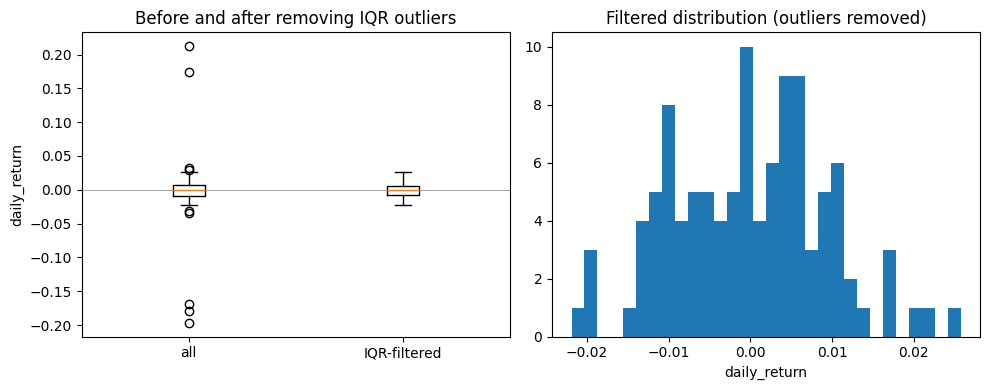

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot([series, series[~df['outlier_iqr']]])
axes[0].set_xticklabels(['all', 'IQR-filtered'])   # set separately: the boxplot
                                                   # `labels=` kwarg was renamed in mpl 3.9
axes[0].set_title('Before and after removing IQR outliers')
axes[0].set_ylabel('daily_return')
axes[0].axhline(0, color='grey', linewidth=0.5)

axes[1].hist(series[~df['outlier_iqr']], bins=30)
axes[1].set_title('Filtered distribution (outliers removed)')
axes[1].set_xlabel('daily_return')

plt.tight_layout()
plt.show()

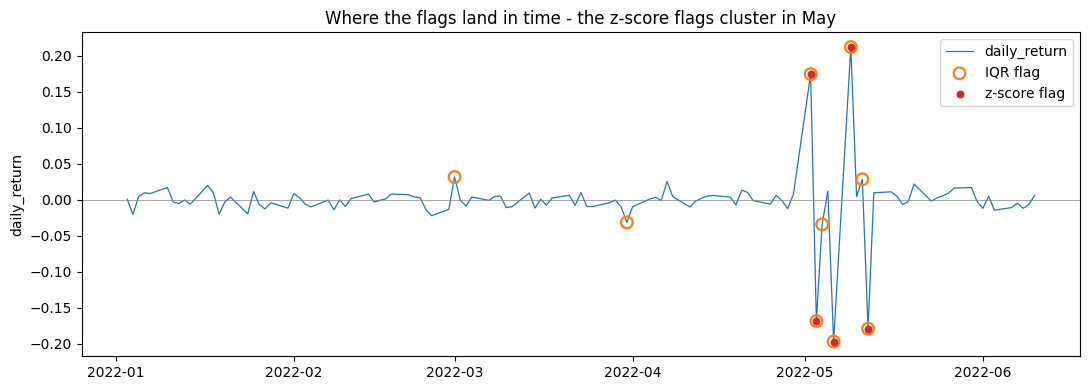

In [11]:
plt.figure(figsize=(11, 4))
plt.plot(df['date'], series, linewidth=0.9, label='daily_return', zorder=1)
plt.scatter(df.loc[df['outlier_iqr'], 'date'], series[df['outlier_iqr']],
            s=70, facecolors='none', edgecolors='tab:orange', linewidths=1.6,
            label='IQR flag', zorder=2)
plt.scatter(df.loc[df['outlier_z'], 'date'], series[df['outlier_z']],
            s=22, color='tab:red', label='z-score flag', zorder=3)
plt.axhline(0, color='grey', linewidth=0.5)
plt.title('Where the flags land in time - the z-score flags cluster in May')
plt.ylabel('daily_return')
plt.legend()
plt.tight_layout()
plt.show()

The time plot is the argument in one picture. The red points sit together in one block;
the four orange-only circles are scattered across March and May and sit visually inside
the ordinary band of variation.

## Step 5 - Sensitivity analysis (a): summary statistics

Four treatments, compared on the same column.

In [12]:
winsorized = outliers.winsorize_series(series, lower=0.05, upper=0.95)

def stats(s):
    return pd.Series({'mean': s.mean(), 'median': s.median(),
                      'std': s.std(), 'min': s.min(), 'max': s.max()})

summary = pd.DataFrame({
    'all':             stats(series),
    'filtered_iqr':    stats(series[~df['outlier_iqr']]),
    'filtered_zscore': stats(series[~df['outlier_z']]),
    'winsorized_5_95': stats(winsorized),
})
summary.round(6)

,all,filtered_iqr,filtered_zscore,winsorized_5_95
mean,-0.001434,-0.000039,-0.000078,-0.000251
median,-0.000187,-0.000100,-0.000100,-0.000187
std,0.040579,0.009443,0.011059,0.010623
min,-0.196672,-0.021860,-0.033999,-0.020590
max,0.212402,0.025708,0.031952,0.020797


The **median barely moves** (−0.000187 → −0.000100) while the **standard deviation falls
by a factor of four** (0.0406 → 0.0094). That contrast is the signature of a small number
of very extreme points: rank-based statistics ignore them, moment-based statistics are
dominated by them.

It also means the choice of treatment matters enormously for anything variance-based -
volatility, value-at-risk, confidence intervals, Sharpe ratios - and hardly at all for
anything median-based. **Which statistic you report decides how much your outlier decision
matters.**

## Step 6 - Sensitivity analysis (b): regression

`daily_return_2` was generated as `0.6 * daily_return + noise`, so there is a known right
answer: **the true slope is 0.6.** Five treatments, judged against it.

In [13]:
def fit_and_score(x, y, label):
    X = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y)
    model = LinearRegression().fit(X, y)
    return pd.Series({
        'slope': model.coef_[0],
        'intercept': model.intercept_,
        'r2': model.score(X, y),
        'mae': mean_absolute_error(y, model.predict(X)),
        'n': len(y),
    }, name=label)

resp = df['daily_return_2']
keep_iqr = ~df['outlier_iqr']
keep_z = ~df['outlier_z']
wins_resp = outliers.winsorize_series(resp, lower=0.05, upper=0.95)

results = pd.DataFrame([
    fit_and_score(series, resp, 'all'),
    fit_and_score(series[keep_iqr], resp[keep_iqr], 'filtered_iqr'),
    fit_and_score(series[keep_z], resp[keep_z], 'filtered_zscore'),
    fit_and_score(winsorized, resp, 'winsorized_x_only'),
    fit_and_score(winsorized, wins_resp, 'winsorized_both'),
])
results.round(4)

,slope,intercept,r2,mae,n
all,0.6059,0.0002,0.9619,0.0040,115.0
filtered_iqr,0.5897,-0.0000,0.5736,0.0039,106.0
filtered_zscore,0.6303,-0.0001,0.6793,0.0038,110.0
winsorized_x_only,1.4672,-0.0003,0.3866,0.0107,115.0
winsorized_both,0.6497,-0.0000,0.6894,0.0037,115.0


### Result 1 - the slope survives everything except bad winsorizing

| treatment | slope | vs true 0.6 |
|---|---|---|
| all | 0.606 | +1% |
| filtered_iqr | 0.590 | −2% |
| filtered_zscore | 0.630 | +5% |
| winsorized_both | 0.650 | +8% |
| **winsorized_x_only** | **1.467** | **+145%** |

The outliers were **not distorting the relationship.** They sit on the same line as
everything else - high leverage, but not influential. Removing them was not a correction;
it was a deletion of five honest observations that happened to be large.

`winsorized_x_only` is the cautionary case. Clipping the predictor while leaving the
response untouched compresses one axis and not the other, and the fitted slope more than
doubles to compensate. It produces a confident, precise, badly wrong number, and nothing
in the output announces the error - `mae` is small and the fit runs without complaint. If
you winsorize a predictor, winsorize the response too, or don't winsorize at all.

### Result 2 - R² collapses, and it is not because the model got worse

R² goes from **0.962** (all) to **0.574** (IQR-filtered). The naive reading is that
removing outliers broke the model. It didn't - the slope hardly moved.

R² is the share of *variance* explained. Filtering removed the points that carried almost
all the variance:

In [14]:
var_all = series.var()
var_filtered = series[keep_iqr].var()

print('variance of daily_return, all data   : %.6f' % var_all)
print('variance after IQR filtering         : %.6f' % var_filtered)
print('share of variance removed            : %.1f%%'
      % (100 * (1 - var_filtered / var_all)))
print('share of ROWS removed                : %.1f%%'
      % (100 * df['outlier_iqr'].mean()))

variance of daily_return, all data   : 0.001647
variance after IQR filtering         : 0.000089
share of variance removed            : 94.6%
share of ROWS removed                : 7.8%


**7.8% of the rows carried 94.6% of the variance.** Delete them and the denominator of R²
collapses while the residual noise stays exactly where it was, so the ratio falls. The
model is just as good; the question it is being graded on got harder.

This is the single most useful thing in this notebook: **R² is not comparable across
datasets with different variance.** Reporting "R² improved after cleaning" is close to
meaningless unless the samples are the same. MAE, which is on the scale of the data
rather than a ratio, barely moves at all here (0.0040 → 0.0039) - which is the honest
signal that nothing much changed.

## Step 7 - Save outputs

In [15]:
out = df.copy()
out['daily_return_winsorized'] = winsorized
out.to_csv('data/processed/outliers_flagged.csv', index=False)

summary.to_csv('data/processed/sensitivity_summary_stats.csv')
results.to_csv('data/processed/sensitivity_regression.csv')

for name in sorted(os.listdir('data/processed')):
    print('%-38s %7d bytes' % (name, os.path.getsize(os.path.join('data/processed', name))))

outliers_flagged.csv                      9441 bytes
sensitivity_regression.csv                 536 bytes
sensitivity_summary_stats.csv              496 bytes


## Reflection

### Methods and thresholds, and why

I ran **IQR (k=1.5)** and **z-score (threshold=3.0)**, and treated the disagreement
between them as the finding rather than picking one and moving on. IQR is rank-based, so
the fences do not move when a shock gets larger; the z-score rule builds its own yardstick
out of contaminated data. On this dataset the z-score rule recovered exactly the five
planted shocks and the IQR rule over-flagged by four.

I would still reach for IQR first on unfamiliar data, because it degrades gracefully. But
I would report **both**, because the gap between them is diagnostic: when they agree, the
extremes are unambiguous; when they diverge, something about the distribution's shape is
worth looking at before either number gets used.

### Assumptions

1. **"Outlier" means *injected shock*, not *large value*.** These are different targets.
   The four points IQR flagged and z-score didn't are ±3% return days - unusual, but the
   kind of day a return series produces legitimately.
2. **The five May shocks are one event, not five errors.** They fall inside nine business
   days. I am assuming that clustering is real signal and not an artifact.
3. **The pre-May drift of −0.0015 is a regime, not contamination.** I left it alone. A
   z-score rule computed separately per regime would flag differently, and I did not test
   that.
4. **`ddof=0`** for the z-score - describing this sample, not inferring about a
   population.

### Observed impacts

- Standard deviation falls **4.3×** under filtering (0.0406 → 0.0094); the median moves
  by 0.00009. Variance-based statistics are entirely at the mercy of this decision;
  rank-based ones are indifferent to it.
- The regression slope stays within a few percent of the true 0.6 under every treatment
  except winsorizing one column, which sends it to **1.467**.
- R² falls from **0.962 to 0.574** while MAE is unchanged, because **7.8% of the rows held
  94.6% of the variance.**
- The z-score flag count is **identical at thresholds 2.0 and 3.5** - sigma is inflated
  enough by the shocks that no threshold in that range separates anything new.

### Risks if the assumptions are wrong

**Discarding true events is the expensive error here.** If the May shocks are real market
moves - and their clustering says they are - then filtering them produces a model that has
never seen a crisis. Volatility would be understated by a factor of four, and every
downstream risk number built on it would inherit that. In a portfolio drift monitor, that
is precisely the scenario the monitor exists to catch, so cleaning it away defeats the
tool.

**The reverse risk is milder but real.** If those five days really were bad data and I
keep them, volatility is overstated and the monitor cries wolf. The cost of a false alarm
is someone's afternoon; the cost of a missed crisis is the portfolio. Given that
asymmetry, **flagging beats deleting**: keep the rows, mark them, and let the person
reading the report decide. That is why `outliers_flagged.csv` retains every row with the
flags as columns rather than shipping a filtered file.

**What I did not test.** Whether the two columns' outliers coincide (I only ever flagged
on `daily_return`); whether a rolling or per-regime threshold behaves differently from a
whole-sample one, which matters for anything that runs daily rather than once; and a
median/MAD rule, which would sidestep the sigma-inflation problem that made the z-score
threshold inert. Any of the three would be the honest next step.